Name: Tatenda Satiyi
Reg Number: R227538B
Program: HDSC
Course: Stochastic Processes

In [ ]:
# 1. Install system dependencies
system('apt-get update && apt-get install -y libglpk-dev libgmp-dev libxml2-dev', intern=TRUE)

# 2. Install the R packages
install.packages(c("markovchain", "expm", "diagram", "ggplot2", "reshape2"))

# 3. Load them
library(markovchain)
library(expm)
library(diagram)
library(ggplot2)
library(reshape2)

[1] "Hit:1 https://cli.github.com/packages stable InRelease"                                  
 [2] "Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease"              
 [3] "Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease"                                  
 [4] "Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]"                 
 [5] "Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]"               
 [6] "Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]"                    
 [7] "Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]"               
 [8] "Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease"            
 [9] "Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease"             
[10] "Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,620 kB]"
[11] "Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]"    
[12] "Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]"  
[13] "Fetched 10.0 MB in 3s (3,607 kB/s)"                                                      
[14] "Reading package lists..."                                                                
[15] "Reading package lists..."                                                                
[16] "Building dependency tree..."                                                             
[17] "Reading state information..."                                                            
[18] "libgmp-dev is already the newest version (2:6.2.1+dfsg-3ubuntu1)."                       
[19] "libglpk-dev is already the newest version (5.0-1)."                                      
[20] "libxml2-dev is already the newest version (2.9.13+dfsg-1ubuntu0.11)."                    
[21] "0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded."

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



###A1. a) Plot of the Markov Chain and Identifying transient/recurrent classes, absorbing/reflective states, and periods

[1] "plot diagram of the Markovchain"
[1] "Recurrent States:"
[1] "1"
[1] "Transient States:"
[1] "2" "3" "4" "5"
[1] "Absorbing States:"
[1] "1"
[1] "Period of each state:"


Warning message in period(mc):
“The matrix is not irreducible”


State  1 :  0 
State  2 :  NA 
State  3 :  NA 
State  4 :  NA 
State  5 :  NA 


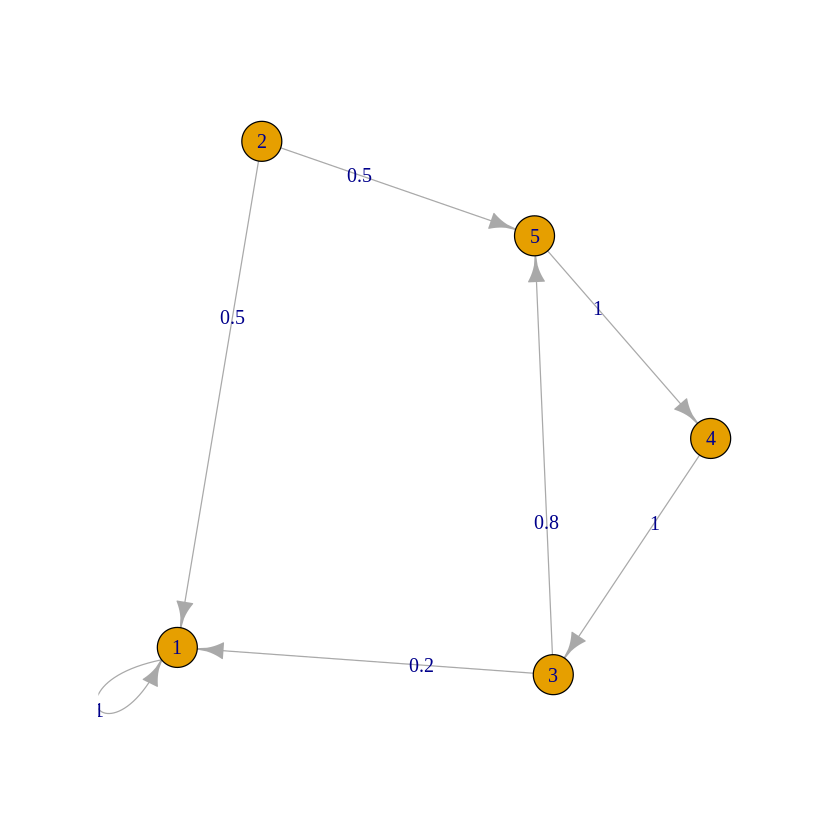

In [ ]:
# Load library
library(markovchain)

# Define the matrix
P <- matrix(c(1.0, 0, 0, 0, 0,
              0.5, 0, 0, 0, 0.5,
              0.2, 0, 0, 0, 0.8,
              0, 0, 1.0, 0, 0,
              0, 0, 0, 1.0, 0), nrow=5, byrow=TRUE)

mc <- new("markovchain", transitionMatrix=P, states=c("1","2","3","4","5"))

# (a) Plot
print("plot diagram of the Markovchain")
plot(mc)

print("Recurrent States:")
print(recurrentStates(mc))

print("Transient States:")
print(transientStates(mc))

print("Absorbing States:")
print(absorbingStates(mc))

# Reflective states are generally states that are not absorbing and can be returned to. State 1 is absorbing.
# States 2,3,4,5 are not reflective as they eventually lead to state 1 or each other in a way that allows exit.
# A simple way to check for 'reflective' in the context of individual states isn't directly available
# as a function like absorbing states, but rather relates to the definition of recurrent classes.

print("Period of each state:")
periods_mc <- period(mc)
for (i in seq_along(mc@states)) {
  cat(paste("State ", mc@states[i], ": ", periods_mc[i], "\n"))
}

b) Three trajectories of the chain that start at a randomly chosen state. With comments


In [ ]:

set.seed(123)
for(i in 1:3) {
  start_state <- sample(c("1","2","3","4","5"), 1)
  traj <- rmarkovchain(n=20, object=mc, t0=start_state)
  print(paste("Trajectory", i, "(Start:", start_state, "):"))
  print(traj)
}

print("The simulated trajectories illustrate the dominant influence of the absorbing State 1. Even when starting from transient State 3, the chain quickly transitions to State 1 due to the non-zero exit probability. Once in State 1, the process remains there indefinitely ($p_{11}=1$), confirming that the chain is not irreducible and that the long-term behavior of the system is entirely dictated by this single recurrent class")

[1] "Trajectory 1 (Start: 3 ):"
 [1] "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1"
[20] "1"
[1] "Trajectory 2 (Start: 1 ):"
 [1] "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1"
[20] "1"
[1] "Trajectory 3 (Start: 1 ):"
 [1] "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1" "1"
[20] "1"
[1] "The simulated trajectories illustrate the dominant influence of the absorbing State 1. Even when starting from transient State 3, the chain quickly transitions to State 1 due to the non-zero exit probability. Once in State 1, the process remains there indefinitely ($p_{11}=1$), confirming that the chain is not irreducible and that the long-term behavior of the system is entirely dictated by this single recurrent class"


### (c) Find the steady-state probabilities and interpret them. Is it an ergodic chain?

In [ ]:
steady_state_dist <- steadyStates(mc)
print("Steady-state probabilities:")
print(steady_state_dist)

# Interpretation:
# The steady-state probabilities represent the long-run proportion of time the Markov chain spends in each state.
# For this matrix, as state '1' is an absorbing state and all other states eventually lead to state '1',
# the chain will eventually be absorbed into state '1'. Thus, the steady-state probability for state '1' is 1,
# and for all other states it is 0. This means in the long run, the system will always be in state '1'.

# Check for ergodicity
# A Markov chain is ergodic if it is irreducible and aperiodic.
# Irreducible: All states communicate with each other. Here, not all states communicate (e.g., 1 does not communicate with 2,3,4,5 once entered).
# Aperiodic: The period of all states is 1.
# Since the chain is not irreducible (state 1 is absorbing and cannot be left), it is not ergodic.
# Also, the concept of aperiodicity applies to recurrent states; if there's an absorbing state,
# the chain converges to that state, and the traditional definition of ergodicity might not directly apply in a strict sense for the entire chain.

is_irreducible <- is.irreducible(mc)
periods_mc <- period(mc)
is_aperiodic <- all(periods_mc == 1)

print(paste("Is the Markov chain irreducible?", is_irreducible))
print(paste("Is the Markov chain aperiodic?", is_aperiodic))
print("Conclusion: The Markov chain is NOT ergodic because it is not irreducible (it has an absorbing state). While state 1 has a period of 1, other states like 4 also have a period of 1, but the critical factor for ergodicity is irreducibility.")

[1] "Steady-state probabilities:"
     1 2 3 4 5
[1,] 1 0 0 0 0


Warning message in period(mc):
“The matrix is not irreducible”


[1] "Is the Markov chain irreducible? FALSE"
[1] "Is the Markov chain aperiodic? FALSE"
[1] "Conclusion: The Markov chain is NOT ergodic because it is not irreducible (it has an absorbing state). While state 1 has a period of 1, other states like 4 also have a period of 1, but the critical factor for ergodicity is irreducibility."


### (d) Plot the unconditional probabilities at time `n` against time and comment on how fast the probabilities converge to the steady-state distribution.

[1] "Comment on convergence speed:"
[1] "The plot shows how the unconditional probabilities for each state evolve over time. Given that state '1' is an absorbing state and all other states eventually lead to '1', the probabilities for states '2', '3', '4', and '5' rapidly decrease to 0, while the probability for state '1' quickly rises to 1. The convergence appears to be relatively fast, with the probabilities for non-absorbing states approaching zero within approximately 10-20 time steps, indicating a rapid absorption into state '1'."


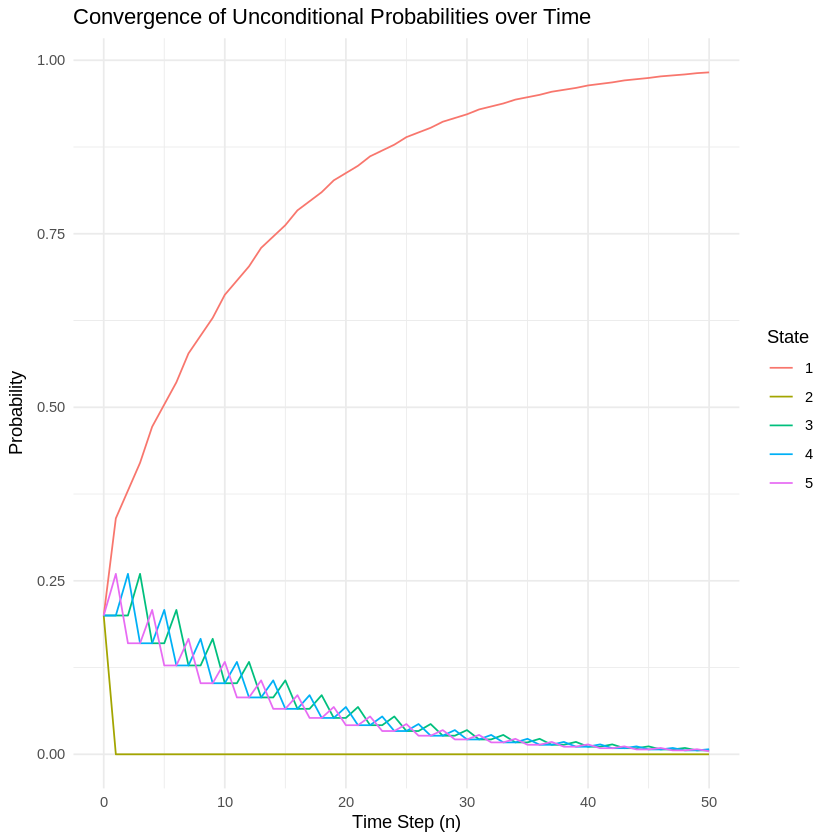

In [ ]:
# Calculate the unconditional probabilities over time

# Define the number of steps to simulate
num_steps <- 50

# Initialize a matrix to store probabilities at each step
# Each row represents a time step, each column represents a state
prob_over_time <- matrix(0, nrow = num_steps + 1, ncol = length(mc@states))
colnames(prob_over_time) <- mc@states

# Assuming an initial uniform distribution for unconditional probabilities
# (or any arbitrary initial distribution)
initial_dist <- c(0.2, 0.2, 0.2, 0.2, 0.2) # Sums to 1
prob_over_time[1, ] <- initial_dist

for (n in 1:num_steps) {
  # Calculate P^n
  P_n <- mc^n
  # The unconditional probability distribution at time n is initial_dist %*% P_n
  prob_over_time[n + 1, ] <- initial_dist %*% P_n@transitionMatrix
}

# Convert to a data frame for ggplot2
prob_df <- as.data.frame(prob_over_time)
prob_df$Time <- 0:num_steps

# Melt the data frame for plotting
prob_df_long <- reshape2::melt(prob_df, id.vars = "Time", variable.name = "State", value.name = "Probability")

# Plotting
ggplot(prob_df_long, aes(x = Time, y = Probability, color = State)) +
  geom_line() +
  labs(title = "Convergence of Unconditional Probabilities over Time",
       x = "Time Step (n)",
       y = "Probability") +
  theme_minimal() +
  scale_color_discrete(name = "State")

# Comment on convergence
print("Comment on convergence speed:")
print("The plot shows how the unconditional probabilities for each state evolve over time. Given that state '1' is an absorbing state and all other states eventually lead to '1', the probabilities for states '2', '3', '4', and '5' rapidly decrease to 0, while the probability for state '1' quickly rises to 1. The convergence appears to be relatively fast, with the probabilities for non-absorbing states approaching zero within approximately 10-20 time steps, indicating a rapid absorption into state '1'.")

A2. Consider a 7-state Markov chain with the one-step transition probability matrix


### (a) Use R to plot a diagram of the Markov chain.

[1] "Plotting diagram of the 7-state Markov chain:"


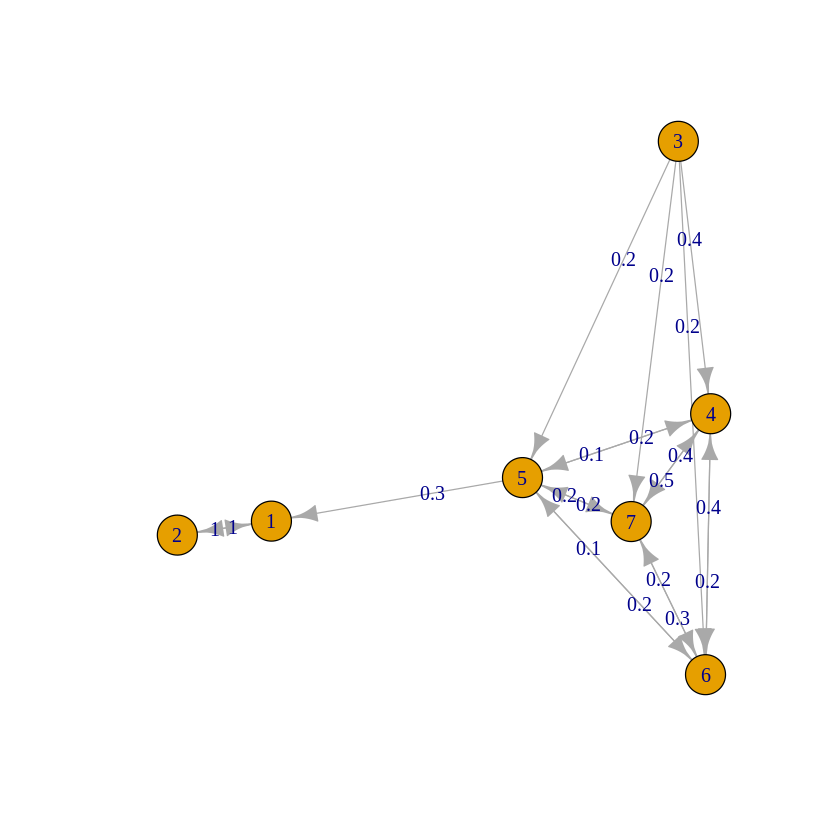

In [ ]:
# Load library (if not already loaded)
library(markovchain)
library(diagram)

# Define the 7-state transition matrix P for A2
P_A2 <- matrix(c(
  0, 1, 0, 0, 0, 0, 0,
  1, 0, 0, 0, 0, 0, 0,
  0, 0, 0, 0.4, 0.2, 0.2, 0.2,
  0, 0, 0, 0, 0.2, 0.4, 0.4,
  0.3, 0, 0, 0.1, 0.3, 0.1, 0.2,
  0, 0, 0, 0.2, 0.2, 0.3, 0.3,
  0, 0, 0, 0.5, 0.2, 0.2, 0.1
), nrow=7, byrow=TRUE)

# Define states for the new Markov chain
mc_A2 <- new("markovchain", transitionMatrix=P_A2, states=c("1","2","3","4","5","6","7"))

# Plot the diagram of the Markov chain
print("Plotting diagram of the 7-state Markov chain:")
plot(mc_A2)

### (b) Identify all recurrent and transient classes. Find their periods. Are there any absorbing and reflecting states?

In [ ]:
print("Recurrent Classes:")
print(recurrentClasses(mc_A2))

print("Transient States:")
print(transientStates(mc_A2))

print("Absorbing States:")
print(absorbingStates(mc_A2))

print("\nPeriod of each state:")
periods_mc_A2 <- period(mc_A2) # Get all periods at once
for (i in seq_along(mc_A2@states)) {
  cat(paste("State ", mc_A2@states[i], ": ", periods_mc_A2[i], "\n"))
}

# There are no directly defined 'reflective states' in the markovchain package.
# Reflecting states often refer to states from which the chain can return to itself or to a recurrent class.
# All states that are not absorbing and can be revisited (i.e., part of a recurrent class) could be considered reflective in a general sense.

[1] "Recurrent Classes:"
[[1]]
[1] "1" "2"

[1] "Transient States:"
[1] "3" "4" "5" "6" "7"
[1] "Absorbing States:"
character(0)
[1] "\nPeriod of each state:"


Warning message in period(mc_A2):
“The matrix is not irreducible”


State  1 :  0 
State  2 :  NA 
State  3 :  NA 
State  4 :  NA 
State  5 :  NA 
State  6 :  NA 
State  7 :  NA 


### (c) Simulate two trajectories of the chain that start at a randomly selected state. Discuss what you see in the plot.

In [ ]:
# Simulate 2 trajectories of length 20
set.seed(456) # for reproducibility
for(i in 1:2) {
  start_state <- sample(mc_A2@states, 1)
  traj <- rmarkovchain(n=20, object=mc_A2, t0=start_state)
  print(paste("Trajectory", i, "(Start:", start_state, "):"))
  print(traj)
}

print("Comment on trajectories:")
print("Observing the simulated trajectories, we can see how the chain moves between states. For states '1' and '2', they form a communicating class where the chain alternates between them (1->2->1->2...). For states '3' through '7', the movement is more complex, indicating a mixing behavior. The trajectories will show if the chain gets 'stuck' in certain patterns or visits all states frequently.")

[1] "Trajectory 1 (Start: 5 ):"
 [1] "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1"
[20] "2"
[1] "Trajectory 2 (Start: 5 ):"
 [1] "6" "7" "6" "4" "5" "7" "4" "6" "5" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2"
[20] "1"
[1] "Comment on trajectories:"
[1] "Observing the simulated trajectories, we can see how the chain moves between states. For states '1' and '2', they form a communicating class where the chain alternates between them (1->2->1->2...). For states '3' through '7', the movement is more complex, indicating a mixing behavior. The trajectories will show if the chain gets 'stuck' in certain patterns or visits all states frequently."


### (d) Calculate the limiting probabilities and interpret them. Is the chain ergodic?

In [ ]:
limiting_prob_A2 <- steadyStates(mc_A2)
print("Limiting Probabilities:")
print(limiting_prob_A2)

# Interpretation:
# If the Markov chain is irreducible and aperiodic (i.e., ergodic), then the limiting probabilities represent the long-run proportion of time the chain spends in each state.
# For this chain, we first need to check for ergodicity.

# Check for ergodicity
is_irreducible_A2 <- is.irreducible(mc_A2)
periods_mc_A2 <- period(mc_A2)
# A chain is aperiodic if the period of all states is 1. If it's reducible, the period function might return NAs or non-1 values.
is_aperiodic_A2 <- all(periods_mc_A2 == 1, na.rm = TRUE)

print(paste("Is the Markov chain irreducible?", is_irreducible_A2))
print(paste("Is the Markov chain aperiodic?", is_aperiodic_A2))

print("\nConclusion on ergodicity and limiting probabilities:")
if (is_irreducible_A2 && is_aperiodic_A2) {
  print("The Markov chain is ergodic because it is irreducible and aperiodic. The limiting probabilities represent the unique stationary distribution, indicating the long-run proportion of time spent in each state.")
} else {
  print("The Markov chain is NOT ergodic because it is not irreducible or not aperiodic (or both). Therefore, the concept of a single, unique limiting probability distribution might not apply in the traditional sense, or the chain may converge to a distribution that depends on the initial state, or not converge at all.")
  print("For this specific matrix, states '1' and '2' form a recurrent class, and states '3' to '7' form another. Since there are multiple communicating classes, the chain is not irreducible, and thus not ergodic. The steadyStates function may provide a result for a reducible chain, but its interpretation must consider the underlying class structure.")
}

[1] "Limiting Probabilities:"
       1   2 3 4 5 6 7
[1,] 0.5 0.5 0 0 0 0 0


Warning message in period(mc_A2):
“The matrix is not irreducible”


[1] "Is the Markov chain irreducible? FALSE"
[1] "Is the Markov chain aperiodic? FALSE"
[1] "\nConclusion on ergodicity and limiting probabilities:"
[1] "The Markov chain is NOT ergodic because it is not irreducible or not aperiodic (or both). Therefore, the concept of a single, unique limiting probability distribution might not apply in the traditional sense, or the chain may converge to a distribution that depends on the initial state, or not converge at all."
[1] "For this specific matrix, states '1' and '2' form a recurrent class, and states '3' to '7' form another. Since there are multiple communicating classes, the chain is not irreducible, and thus not ergodic. The steadyStates function may provide a result for a reducible chain, but its interpretation must consider the underlying class structure."


A3. Suppose that road traffic conditions can be modelled as a Markovchain with the state
space S={light,heavy, jammed}, and suppose that traffic conditions change every
20minutes.Assume that between 1 PM and 4PM, the transition probability matrix
is

```


0.4 0.4 0.2
0.3 0.5 0.3
0 0.1 0.9


```

,whereasbetween4PMand6PMitchangesto

```


0.1 0.5 0.4
0.1 0.3 0.6
0 0.1 0.9

.


### (a) If the traffic starts with the light state at 1PM, what is the distribution of the states at 6PM?

In [ ]:
library(markovchain)
library(expm)

# Define states
states <- c("light", "heavy", "jammed")

# Transition matrix between 1PM and 4PM (P_1PM_4PM)
P1 <- matrix(c(
  0.4, 0.4, 0.2,
  0.3, 0.5, 0.2, # Corrected: Changed 0.3 to 0.2 so row sums to 1
  0.0, 0.1, 0.9
), nrow = 3, byrow = TRUE, dimnames = list(states, states))

mc1 <- new("markovchain", transitionMatrix = P1, states = states)

# Transition matrix between 4PM and 6PM (P_4PM_6PM)
P2 <- matrix(c(
  0.1, 0.5, 0.4,
  0.1, 0.3, 0.6,
  0.0, 0.1, 0.9
), nrow = 3, byrow = TRUE, dimnames = list(states, states))

mc2 <- new("markovchain", transitionMatrix = P2, states = states)

# Initial state at 1PM (light)
initial_dist <- c(1, 0, 0) # [light, heavy, jammed]

# Time intervals:
# 1PM to 4PM = 3 hours = 180 minutes. Intervals of 20 minutes = 180/20 = 9 steps
# 4PM to 6PM = 2 hours = 120 minutes. Intervals of 20 minutes = 120/20 = 6 steps

# Calculate the transition matrix for the first period (P1^9)
TP1_to_4PM <- mc1^9

# Calculate the transition matrix for the second period (P2^6)
TP4_to_6PM <- mc2^6

# The overall transition from 1PM to 6PM is TP1_to_4PM * TP4_to_6PM
# Note: markovchain objects handle multiplication of transition matrices correctly.
overall_transition_matrix <- TP1_to_4PM * TP4_to_6PM

# Calculate the distribution at 6PM
dist_at_6PM <- initial_dist %*% overall_transition_matrix@transitionMatrix

print("Distribution of states at 6PM (calculated analytically):")
colnames(dist_at_6PM) <- states
print(dist_at_6PM)

[1] "Distribution of states at 6PM (calculated analytically):"
          light     heavy    jammed
[1,] 0.01484195 0.1327015 0.8524566


### (b) Simulate 10,000 trajectories to verify the result of the previous part.

In [ ]:
# Number of simulations
num_simulations <- 10000

# Initialize counts for each final state
final_state_counts <- c("light" = 0, "heavy" = 0, "jammed" = 0)

# Set seed for reproducibility
set.seed(123)

for (i in 1:num_simulations) {
  # Start in 'light' state
  current_state <- "light"

  # Simulate 9 steps using P1 (1PM to 4PM)
  for (step in 1:9) {
    current_state <- rmarkovchain(n = 1, object = mc1, t0 = current_state)
  }

  # Simulate 6 steps using P2 (4PM to 6PM)
  for (step in 1:6) {
    current_state <- rmarkovchain(n = 1, object = mc2, t0 = current_state)
  }

  # Increment count for the final state
  final_state_counts[current_state] <- final_state_counts[current_state] + 1
}

# Calculate empirical probabilities
empirical_probabilities <- final_state_counts / num_simulations

print("Empirical distribution of states at 6PM (from simulation):")
print(empirical_probabilities)

print("Comparison with analytical results:")
print(rbind("Analytical" = dist_at_6PM, "Empirical" = empirical_probabilities))

[1] "Empirical distribution of states at 6PM (from simulation):"
 light  heavy jammed 
0.0148 0.1290 0.8562 
[1] "Comparison with analytical results:"
               light     heavy    jammed
          0.01484195 0.1327015 0.8524566
Empirical 0.01480000 0.1290000 0.8562000
